In [1]:
!pip install torchinfo

In [2]:

import os
import re
import cv2
import time
import glob
import random
import shutil
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from tabulate import tabulate
from tqdm import tqdm, notebook
from PIL import Image, ImageOps
import PIL
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    ColorJitter, RandomRotation, RandomResizedCrop
)
from torchvision.transforms.functional import gaussian_blur

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torchinfo import summary


This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


To ensure consistent and repeatable results across different runs, a fixed random seed is set here.
This controls the randomness in:
PyTorch CPU and GPU operations (torch.manual_seed, torch.cuda.manual_seed)
NumPy and Python’s built-in random module
Using the same seed guarantees that data shuffling, weight initialization, and other random processes produce the same outputs each time the notebook is executed.

In [4]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [ ]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)

df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))

for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [ ]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
        
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [8]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/1200087188083506.jpg,Good
1,/kaggle/working/dataset/Good/832070427389063.jpg,Good
2,/kaggle/working/dataset/Good/2580133548953307.jpg,Good
3,/kaggle/working/dataset/Good/213058670626092.jpg,Good
4,/kaggle/working/dataset/Good/369265614511098.jpg,Good
5,/kaggle/working/dataset/Good/4294966113867856.jpg,Good
6,/kaggle/working/dataset/Good/626425258265563.jpg,Good
7,/kaggle/working/dataset/Good/917764679065641.jpg,Good
8,/kaggle/working/dataset/Good/544529173530317.jpg,Good
9,/kaggle/working/dataset/Good/1070150156981926.jpg,Good


This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

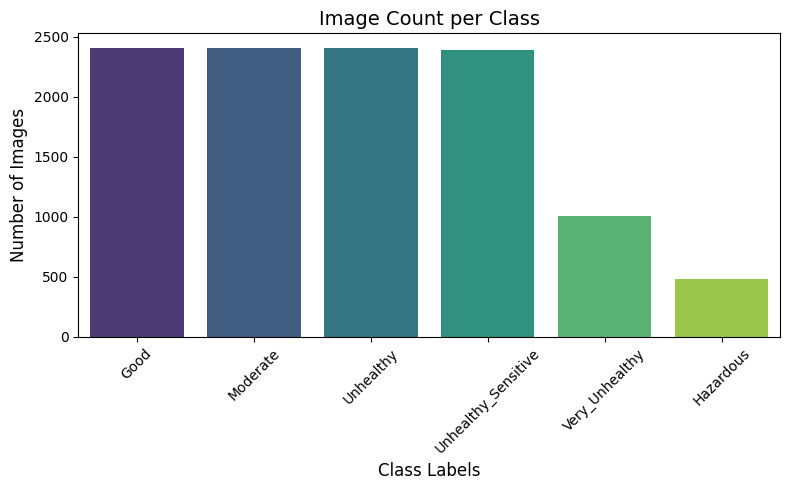

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

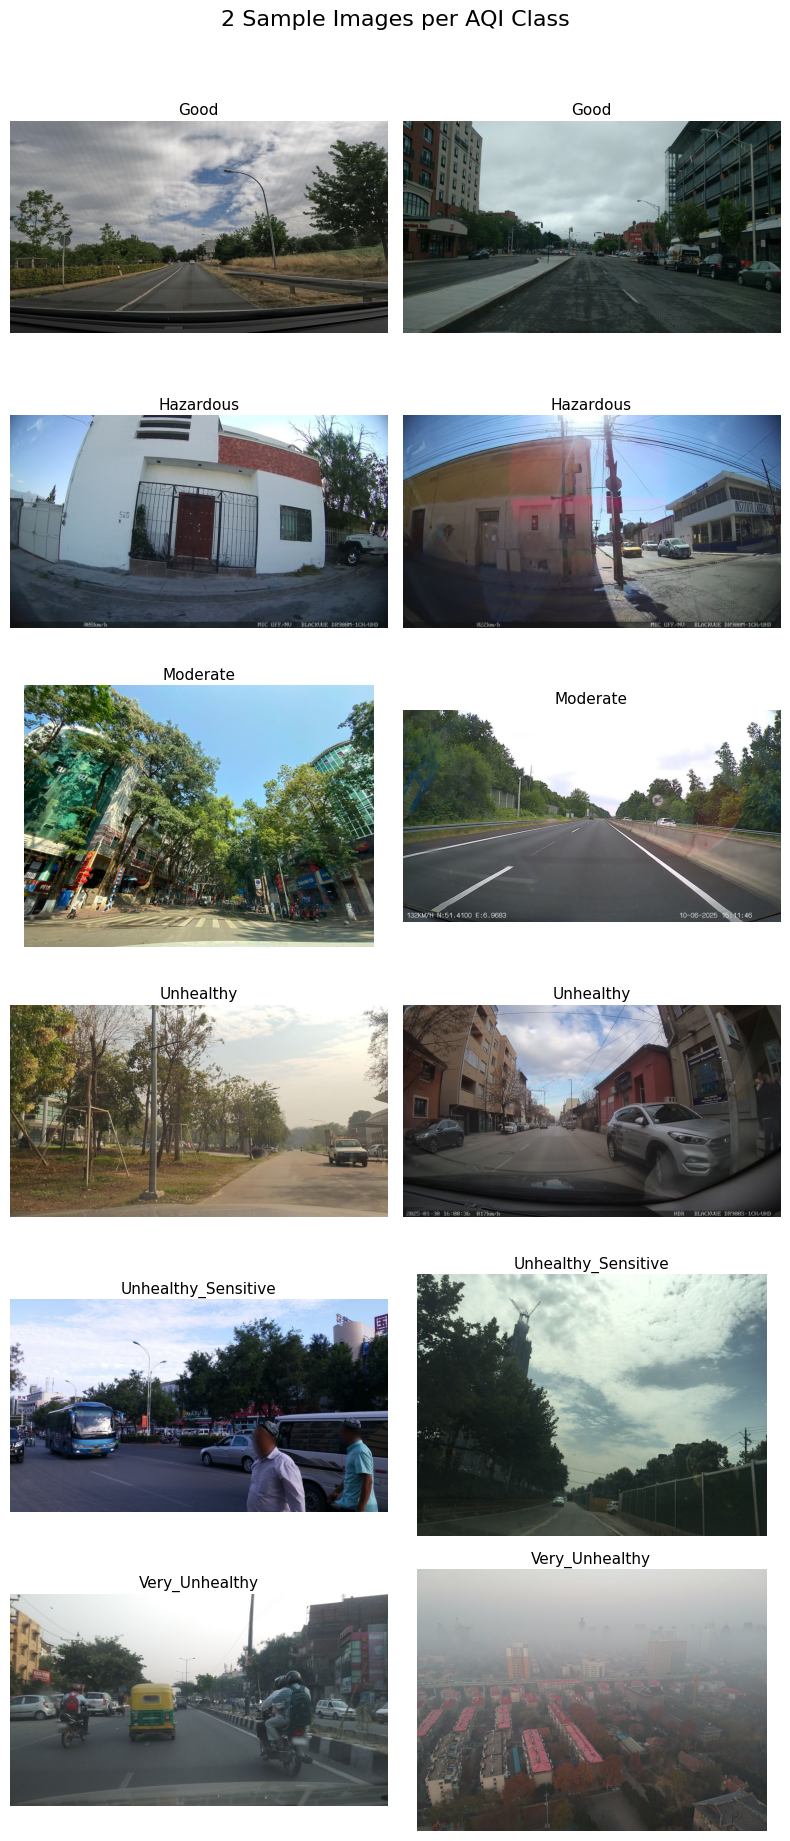

In [10]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This block divides the dataset into train, validation, and test sets for multiple ratios (from 90:10 down to 10:90).
Each split is stratified by class labels to keep class balance and uses a fixed random seed (42) for reproducibility.
From the training portion, 10% is further used as validation.
All splits are saved in dictionaries (SPLITS, FIXED_IDX) and a summary table shows image counts for every ratio

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path
import numpy as np
import os


OUT_DIR = Path("/kaggle/working/dataset")

rows = []
for class_dir in sorted([p for p in OUT_DIR.iterdir() if p.is_dir()]):
    label = class_dir.name
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(img_path), "label": label})

df = pd.DataFrame(rows)
print(f"✅ Found total {len(df)} images across {df['label'].nunique()} classes.")

RATIOS = [(90,10),(80,20),(70,30),(60,40),(50,50),(40,60),(30,70),(20,80),(10,90)]
RANDOM_STATE = 42


SPLITS = {}  
FIXED_IDX = {} 
all_idx = np.arange(len(df))
labels_all = df["label"].values


for tr, te in RATIOS:
    test_size = te / 100.0

    train_pool_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=labels_all,
        random_state=RANDOM_STATE
    )
    FIXED_IDX[(tr, te)] = {
        "train_pool_idx": train_pool_idx,
        "test_idx": test_idx
    }

    train_pool_df = df.iloc[train_pool_idx].reset_index(drop=True)
    tr_local_idx, va_local_idx = train_test_split(
        np.arange(len(train_pool_df)),
        test_size=0.10,
        stratify=train_pool_df["label"].values,
        random_state=RANDOM_STATE
    )

    train_idx = train_pool_idx[tr_local_idx]
    valid_idx = train_pool_idx[va_local_idx]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    SPLITS[(tr, te)] = {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df":  test_df
    }


print("\n=== Split Summary (counts) ===")
for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    print(f"{tr}:{te} -> train={len(s['train_df'])}, val={len(s['valid_df'])}, test={len(s['test_df'])}")
print("-------------------------------------------")
print("Total images in dataset: ", len(df))


✅ Found total 11103 images across 6 classes.

=== Split Summary (counts) ===
90:10 -> train=8992, val=1000, test=1111
80:20 -> train=7993, val=889, test=2221
70:30 -> train=6994, val=778, test=3331
60:40 -> train=5994, val=667, test=4442
50:50 -> train=4995, val=556, test=5552
40:60 -> train=3996, val=445, test=6662
30:70 -> train=2997, val=333, test=7773
20:80 -> train=1998, val=222, test=8883
10:90 -> train=999, val=111, test=9993
-------------------------------------------
Total images in dataset:  11103


This block prints class-wise image counts for train, validation, and test sets at each ratio using the tabulate library.
It helps verify that all splits remain balanced across classes and that no samples are missing.

In [12]:
from tabulate import tabulate

for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    train_df = s["train_df"]; valid_df = s["valid_df"]; test_df = s["test_df"]

    class_counts_train = train_df['label'].value_counts()
    class_counts_valid = valid_df['label'].value_counts()
    class_counts_test  = test_df['label'].value_counts()

    train_table_data = [[class_name, count] for class_name, count in class_counts_train.items()]
    valid_table_data = [[class_name, count] for class_name, count in class_counts_valid.items()]
    test_table_data  = [[class_name, count]  for class_name, count  in class_counts_test.items()]

    print(f"\n=== {tr}:{te} Split ===")
    print("\n Train Dataset")
    print(tabulate(train_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Validation Dataset")
    print(tabulate(valid_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Test Dataset")
    print(tabulate(test_table_data, headers=["Class", "Count"], tablefmt="github"))



=== 90:10 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |    1950 |
| Unhealthy           |    1949 |
| Moderate            |    1949 |
| Unhealthy_Sensitive |    1939 |
| Very_Unhealthy      |     815 |
| Hazardous           |     390 |

 Validation Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     217 |
| Moderate            |     217 |
| Unhealthy           |     217 |
| Unhealthy_Sensitive |     215 |
| Very_Unhealthy      |      91 |
| Hazardous           |      43 |

 Test Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     241 |
| Unhealthy           |     241 |
| Moderate            |     241 |
| Unhealthy_Sensitive |     239 |
| Very_Unhealthy      |     101 |
| Hazardous           |      48 |

=== 80:20 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Creates a base folder /kaggle/working/task2_resnet50 to store model checkpoints, logs, and outputs.
Ensures the directory exists before training begins.

In [14]:

save_root_base = "/kaggle/working/task2_vit_b16"
os.makedirs(save_root_base, exist_ok=True)

Defines a reusable ImageDataset class for loading PM25Vision images in PyTorch.
It
Reads image paths and labels from a DataFrame.
Converts labels into numeric indices via a mapping dictionary.
Loads each image in RGB format and applies given normalization transforms.
Optionally returns labels (is_lb=True) for training or just images for inferen

In [15]:
import PIL.Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=True):
        """
        Args:
            dataframe : pd.DataFrame containing 'path' and 'label' columns
            normalize : torchvision.transforms to apply to images
            is_lb     : bool, True if labels should be returned
        """
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['path']
        image = PIL.Image.open(img_path).convert("RGB")  

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

Implemented data transformation and DataLoader setup for ViT-B16 model.
 Added ImageNet normalization pipeline (Resize → ToTensor → Normalize).
 Created custom datasets for train, validation, and test using ImageDataset class.
 Configured DataLoaders with batch sizes 32 (train) and 8 (val/test) and 2 worker threads.
 Ensures consistent preprocessing and efficient batching for ViT-B16 experiments.

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

train_batch = 32
val_batch = 8

def data_transform(train_df, valid_df, test_df):

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    normalize = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    train_dataset = ImageDataset(
        train_df,
        normalize,
        is_lb=True
    )

    valid_dataset = ImageDataset(
        valid_df,
        normalize,
        is_lb=True
    )

    test_dataset = ImageDataset(
        test_df,
        normalize,
        is_lb=True
    )

    dataloader_train_dataset = DataLoader(
        train_dataset, batch_size=train_batch, shuffle=True, num_workers=2
    )
    dataloader_valid_dataset = DataLoader(
        valid_dataset, batch_size=val_batch, shuffle=False, num_workers=2
    )
    dataloader_test_dataset = DataLoader(
        test_dataset, batch_size=val_batch, shuffle=False, num_workers=2
    )

    return dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset


Initialized ViT-B16 model and computed complexity metrics.
 Loaded pretrained ViT-B16 and replaced the final classification head for target classes.
 Configured Adam optimizer (lr = 0.0001) and CrossEntropyLoss for training setup.
 Used THOP to estimate computational cost: MACs, FLOPs, and parameter count.
 Printed model complexity summary at 224×224 input resolution for performance benchmarking.


In [ ]:
total_class = len(df['label'].unique())   
learning_rate = 0.0001

model = models.vit_b_16(pretrained=True)

num_ftrs = model.heads.head.in_features
model.heads.head = nn.Linear(num_ftrs, total_class)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(train_batch, 3, 224, 224))

try:
    from thop import profile
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "thop"])
    from thop import profile

model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    macs, params = profile(model, inputs=(dummy,), verbose=False)

gmacs  = macs / 1e9
gflops = (2 * macs) / 1e9  
mparams = params / 1e6

print(f"[Complexity @224x224]  MACs: {gmacs:.2f} GMACs  (~{gflops:.2f} GFLOPs)  |  Params: {mparams:.2f} M")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 199MB/s]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


[Complexity @224x224]  MACs: 11.29 GMACs  (~22.57 GFLOPs)  |  Params: 57.30 M


Added full training pipeline for ViT-B/16 across all train:test ratios.
 Defined train_model() to handle training, validation, and checkpoint saving (best model based on validation accuracy).
 Configured ViT-B/16 with Adam optimizer and CrossEntropyLoss.
 Trained for 20 epochs per ratio, recording timing, losses, and accuracies.
 Saved per-epoch metrics to training_data.xlsx in each checkpoint folder.
 Printed total runtime and per-epoch statistics for all ratios.


In [ ]:
start_time_global = time.time()

def train_model(model, criterion, optimizer, dataloader_train_dataset, dataloader_valid_dataset, num_epochs=20, save_path_checkpoints="checkpoints"):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    os.makedirs(save_path_checkpoints, exist_ok=True)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        progress_bar = tqdm(enumerate(dataloader_train_dataset), total=len(dataloader_train_dataset))
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(loss=running_loss / total_train, acc=correct_train / total_train)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        print('Training Loss: {:.3f} Acc: {:.3f}'.format(epoch_train_loss, epoch_train_acc))

        # --- Validation phase ---
        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in dataloader_valid_dataset:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                running_loss += loss.item() * inputs.size(0)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        print('Validation Loss: {:.3f} Acc: {:.3f}'.format(epoch_val_loss, epoch_val_acc))

        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1} Time: {epoch_time:.2f} seconds")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            filepath = f"{save_path_checkpoints}/model.pt"
            checkpoint = {
                "epoch": epoch + 1,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }
            torch.save(checkpoint, filepath)
            print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.3f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history


import json
RESULTS_ROWS = []  
for (tr, te) in RATIOS:
    print(f"\n================= Running ViT-B/16 for ratio {tr}:{te} =================")
    split = SPLITS[(tr, te)]
    tr_df = split["train_df"]; va_df = split["valid_df"]; te_df = split["test_df"]

    dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset = data_transform(tr_df, va_df, te_df)

    model_ratio = models.vit_b_16(pretrained=True)
    num_ftrs = model_ratio.heads.head.in_features
    model_ratio.heads.head = nn.Linear(num_ftrs, len(df['label'].unique()))
    model_ratio = model_ratio.to(device)

    optimizer_ratio = optim.Adam(model_ratio.parameters(), lr=learning_rate)
    criterion_ratio = nn.CrossEntropyLoss()

    save_path_checkpoints = os.path.join(save_root_base, f"{tr}_{te}")
    os.makedirs(save_path_checkpoints, exist_ok=True)

    start_time = time.time()

    train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
        model_ratio, criterion_ratio, optimizer_ratio,
        dataloader_train_dataset, dataloader_valid_dataset,
        num_epochs=20, save_path_checkpoints=save_path_checkpoints
    )

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time [{tr}:{te}]: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")
    print(f"Average Per-Epoch Time [{tr}:{te}]: {training_time/20:.2f} seconds/epoch")

    data_hist = {
        'Epoch': list(range(1, len(train_loss_history) + 1)),
        'Train Loss': train_loss_history,
        'Train Accuracy': train_acc_history,
        'Validation Loss': val_loss_history,
        'Validation Accuracy': val_acc_history
    }
    history = pd.DataFrame(data_hist)
    hist_path = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    history.to_excel(hist_path, index=False)

    RESULTS_ROWS.append({
        "ratio": f"{tr}:{te}",
        "checkpoint_dir": save_path_checkpoints,
        "history_path": hist_path
    })


end_time_global = time.time()
print(f"\n=== All ViT ratios done in {end_time_global - start_time_global:.2f} seconds ===")



================= Running ViT-B/16 for ratio 90:10 =================


Epoch 1/20: 100%|██████████| 281/281 [02:53<00:00,  1.62it/s, acc=0.449, loss=1.31]

Training Loss: 1.310 Acc: 0.449


Validation Loss: 1.155 Acc: 0.515
Epoch 1 Time: 182.04 seconds
Best model saved at epoch 1 with validation accuracy: 0.515


Epoch 2/20: 100%|██████████| 281/281 [02:54<00:00,  1.61it/s, acc=0.636, loss=0.88]

...

Training Loss: 0.001 Acc: 1.000


Validation Loss: 3.294 Acc: 0.333
Epoch 19 Time: 21.34 seconds


Epoch 20/20: 100%|██████████| 32/32 [00:20<00:00,  1.60it/s, acc=1, loss=0.000756]

Training Loss: 0.001 Acc: 1.000


Validation Loss: 3.326 Acc: 0.360
Epoch 20 Time: 21.27 seconds
Training Time [10:90]: 431.89 seconds ---> 7.20 minutes
Average Per-Epoch Time [10:90]: 21.59 seconds/epoch

=== All ViT ratios done in 18504.14 seconds ===


Added visualization of ViT-B16 training progress across all split ratios.
 Loaded training histories (`training_data.xlsx`) for each (train:test) ratio.
 Plotted side-by-side subplots of Train vs Validation Loss and Accuracy over epochs.
 Saved each figure as `curves.png` in the respective checkpoint folder.
 Enables quick visual inspection of convergence and overfitting trends for ViT-B16 runs.


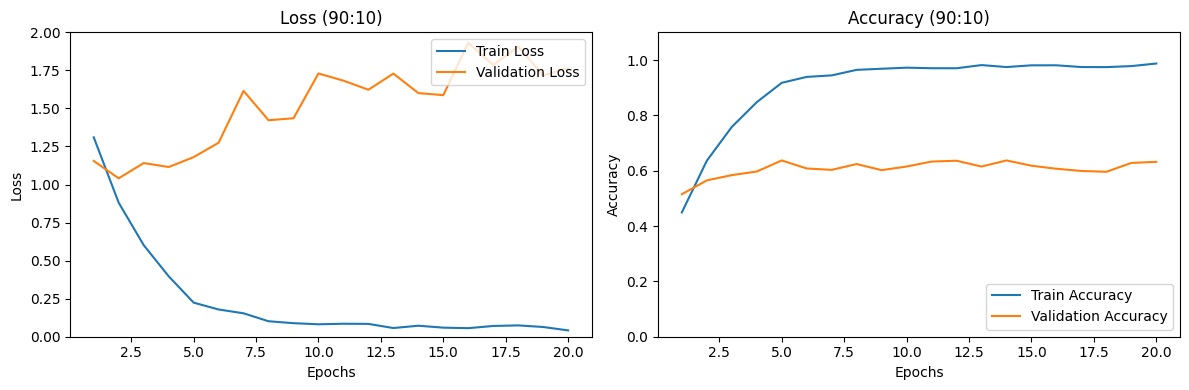

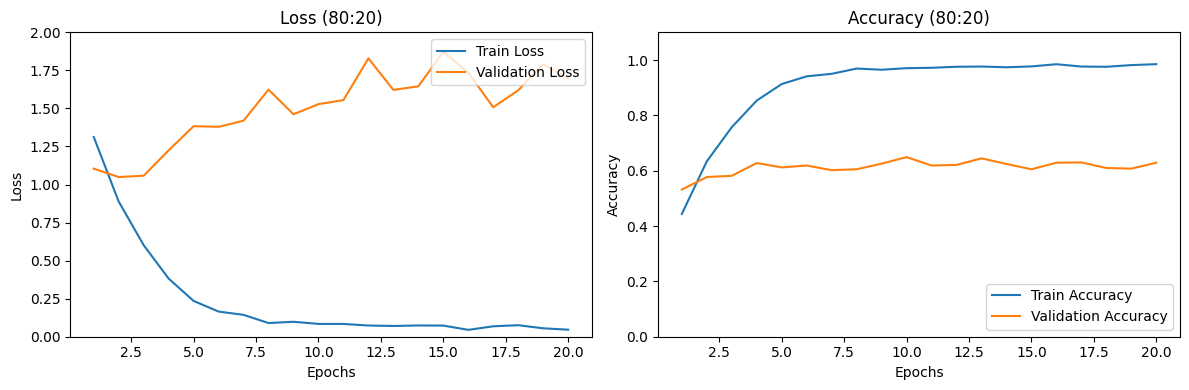

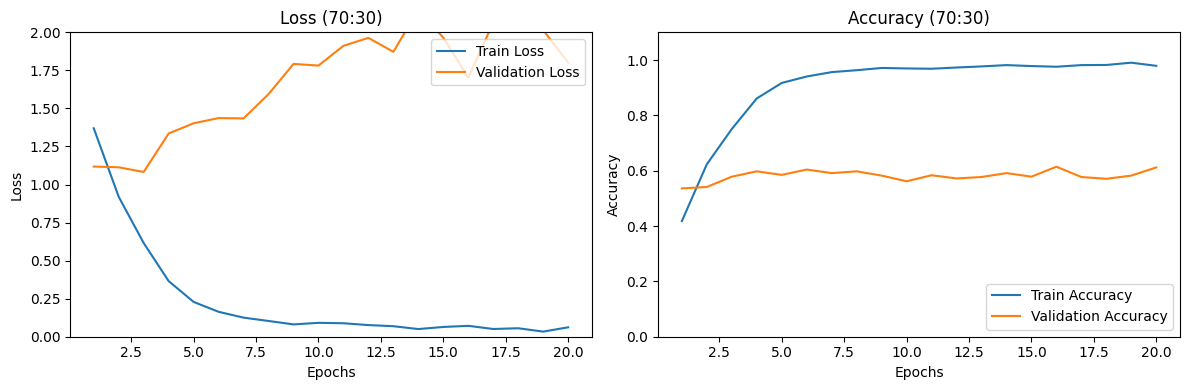

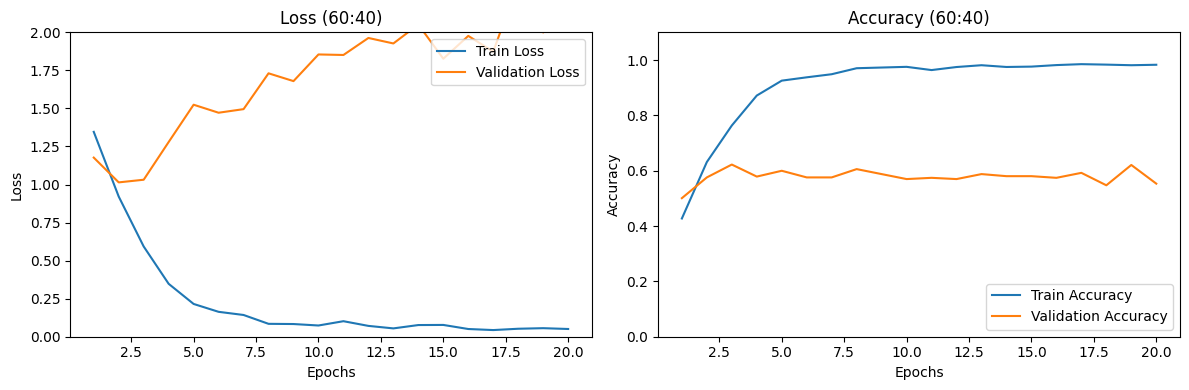

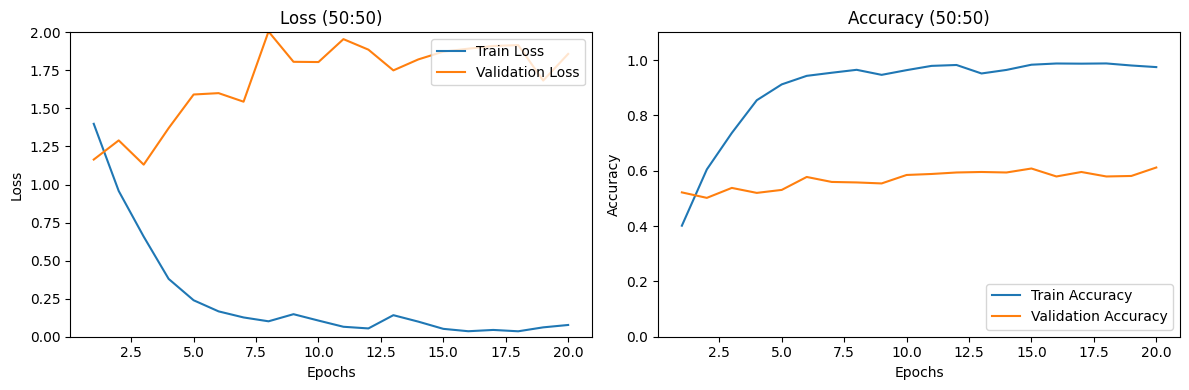

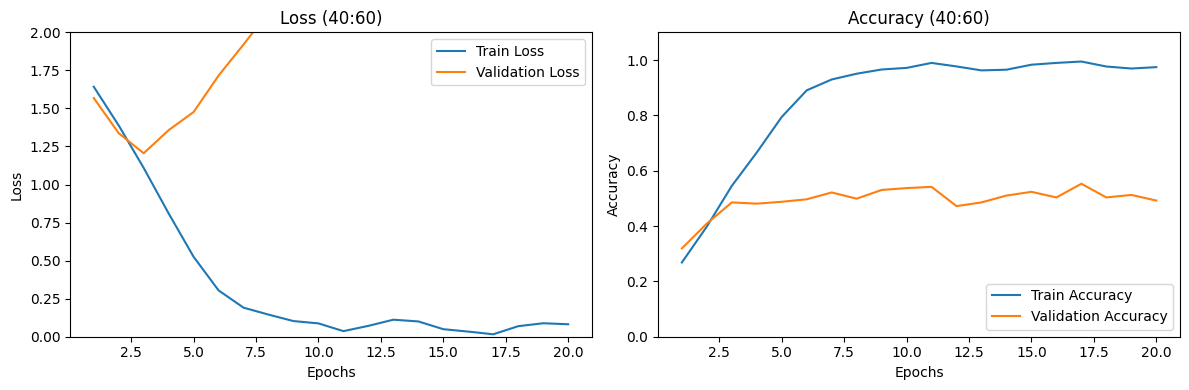

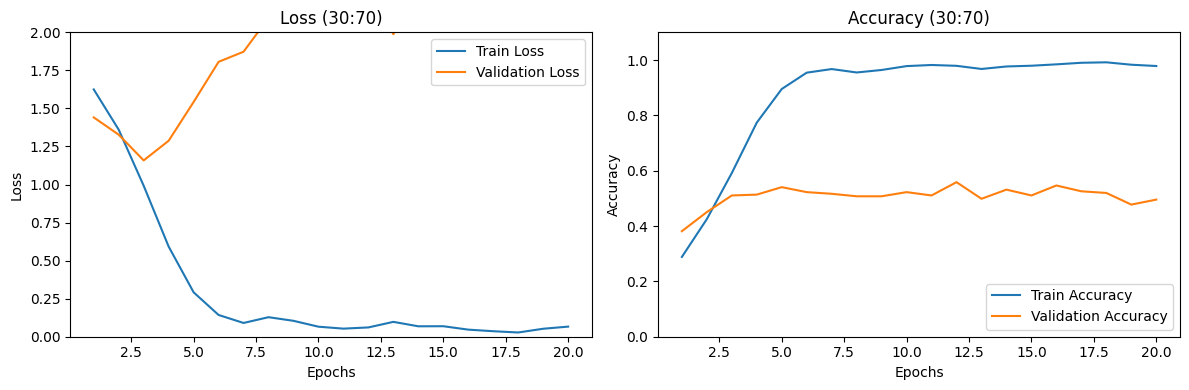

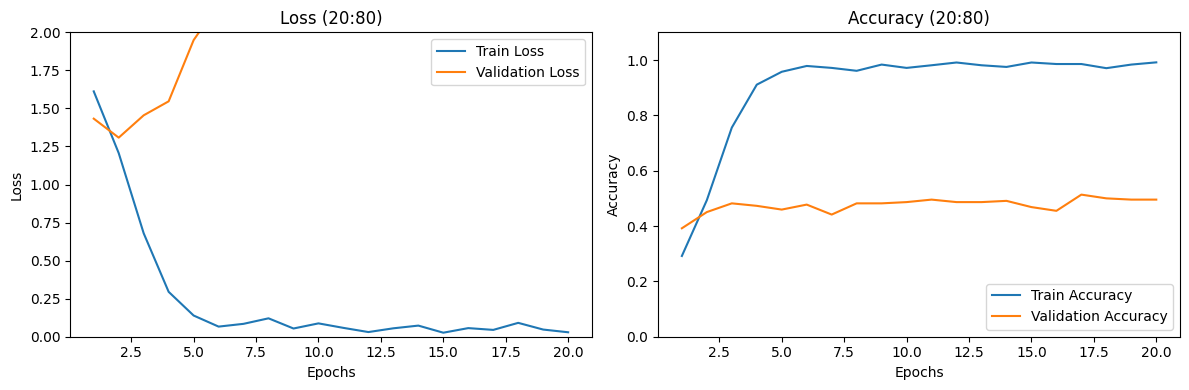

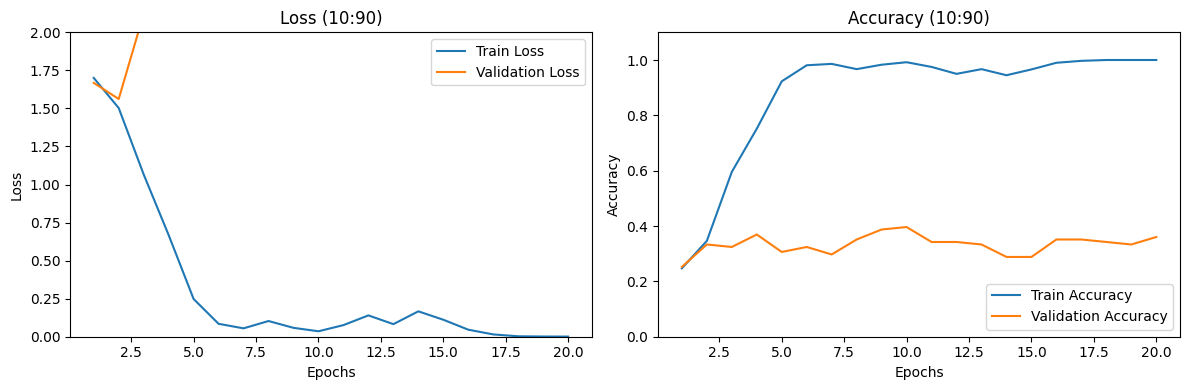

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

for (tr, te) in RATIOS:
    save_path_checkpoints = os.path.join("/kaggle/working/task2_vit_b16", f"{tr}_{te}")
    hist_xlsx = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    if not os.path.exists(hist_xlsx):
        print(f"[{tr}:{te}] history file missing at {hist_xlsx}")
        continue

    history = pd.read_excel(hist_xlsx)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss')
    plt.plot(history['Epoch'], history['Validation Loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss ({tr}:{te})')
    plt.legend(loc='upper right')
    plt.ylim(0, 2)

    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy')
    plt.plot(history['Epoch'], history['Validation Accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy ({tr}:{te})')
    plt.legend(loc='lower right')
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plot_path = os.path.join(save_path_checkpoints, "curves.png")
    plt.savefig(plot_path)
    plt.show()

Implemented generic evaluate_model() function for model evaluation.
 Evaluates any PyTorch model on a given DataLoader using the specified loss criterion.
 Computes average loss and overall accuracy.
 Optionally returns predictions, true labels, and softmax probabilities when return_preds=True.
 Runs in torch.no_grad() mode to disable gradient computation and improve efficiency.


In [20]:
import torch
import numpy as np

def evaluate_model(model, criterion, dataloader, return_preds=False):
    """
    Evaluate model on given dataloader.

    Args:
        model: PyTorch model
        criterion: loss function
        dataloader: DataLoader for evaluation
        return_preds: bool, if True returns all predictions and labels (and probs)

    Returns:
        loss: average loss
        accuracy: overall accuracy
        (optional) all_preds, all_labels, all_probs (softmax)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if return_preds:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    loss = running_loss / total 
    accuracy = correct / total

    if return_preds:
        return loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    else:
        return loss, accuracy

This Block added validation evaluation step for ViT-B16 across all train:test ratios.
 Reloads best model checkpoint (model.pt) for each ratio and restores weights & optimizer state.
 Builds validation DataLoader and evaluates performance using evaluate_model().
 Prints best epoch, validation loss, and accuracy for quick performance comparison across splits.


In [ ]:
import os
import torch

for (tr, te) in RATIOS:
    print(f"\n[Validation Eval] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_vit_b16", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    model = models.vit_b_16(pretrained=True).to(device)
    num_ftrs = model.heads.head.in_features
    model.heads.head = nn.Linear(num_ftrs, len(df['label'].unique()))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_epoch = checkpoint["epoch"]
    model.load_state_dict(checkpoint["model_weight"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])  


    split = SPLITS[(tr, te)]
    _, dataloader_valid_dataset, _ = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    best_val_loss, best_val_accuracy = evaluate_model(model, criterion, dataloader_valid_dataset)
    print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")


[Validation Eval] Ratio 90:10


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Best model (from epoch 5) - Validation Loss: 1.180, Validation Accuracy: 0.637

[Validation Eval] Ratio 80:20
Best model (from epoch 10) - Validation Loss: 1.528, Validation Accuracy: 0.649

[Validation Eval] Ratio 70:30
Best model (from epoch 16) - Validation Loss: 1.703, Validation Accuracy: 0.614

[Validation Eval] Ratio 60:40
Best model (from epoch 3) - Validation Loss: 1.032, Validation Accuracy: 0.622

[Validation Eval] Ratio 50:50
Best model (from epoch 20) - Validation Loss: 1.858, Validation Accuracy: 0.612

[Validation Eval] Ratio 40:60
Best model (from epoch 17) - Validation Loss: 2.262, Validation Accuracy: 0.553

[Validation Eval] Ratio 30:70
Best model (from epoch 12) - Validation Loss: 2.273, Validation Accuracy: 0.559

[Validation Eval] Ratio 20:80
Best model (from epoch 17) - Validation Loss: 2.391, Validation Accuracy: 0.514

[Validation Eval] Ratio 10:90
Best model (from epoch 10) - Validation Loss: 2.913, Validation Accuracy: 0.396


This block added final test evaluation and diagnostics for ViT-B16 across all split ratios.
 Loaded best model checkpoints for each (train:test) ratio and evaluated on the test set.
 Computed overall test loss, accuracy, and average inference time per image.
 Generated per-class accuracy, classification report, and macro ROC–AUC (OvR).
 Plotted and saved normalized confusion matrices and ROC curves for each ratio.
 Identified top confused class pairs to analyze model misclassifications.



[TEST] Ratio 90:10
Test Loss: 1.275, Test Accuracy: 0.608
Total Test Time: 10.60 seconds for 1111 images
Average Inference Time per Image: 0.009539 s (~9.54 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.651452
1            Hazardous  0.770833
2             Moderate  0.290456
3            Unhealthy  0.746888
4  Unhealthy_Sensitive  0.615063
5       Very_Unhealthy  0.831683

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5587    0.6515    0.6015       241
          Hazardous     0.7115    0.7708    0.7400        48
           Moderate     0.4667    0.2905    0.3581       241
          Unhealthy     0.7171    0.7469    0.7317       241
Unhealthy_Sensitive     0.6049    0.6151    0.6100       239
     Very_Unhealthy     0.6269    0.8317    0.7149       101

           accuracy                         0.6076      1111
          macro avg     0.6143    0.6511    0.6260      1111
    

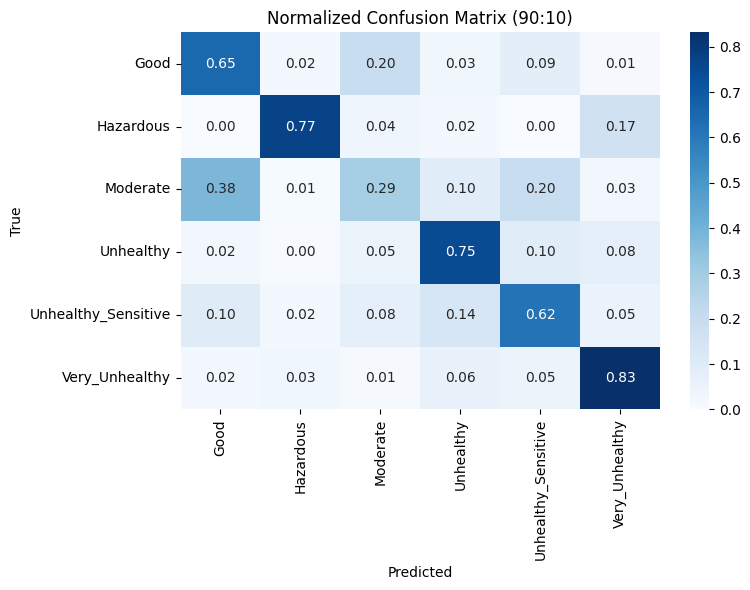

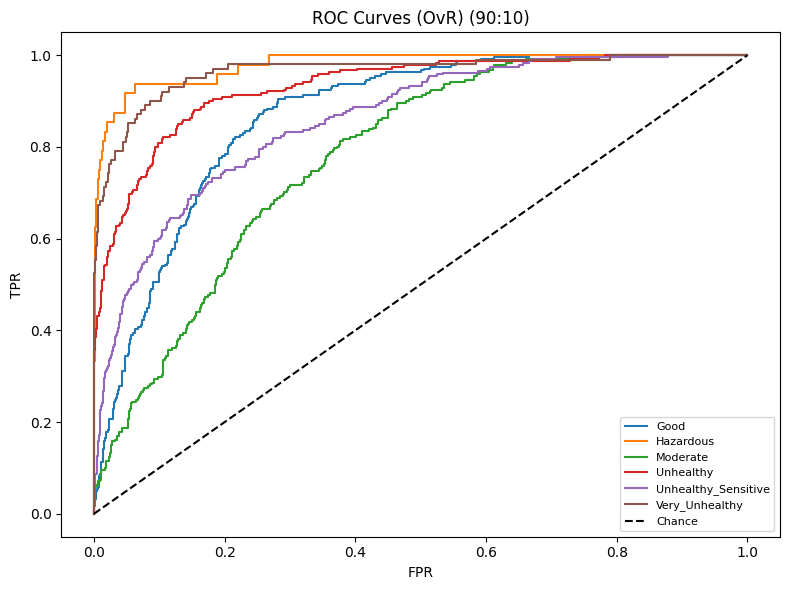


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.38
                Good → Moderate           : 0.20
            Moderate → Unhealthy_Sensitive : 0.20
           Hazardous → Very_Unhealthy     : 0.17
  Unhealthy_Sensitive → Unhealthy          : 0.14

[TEST] Ratio 80:20
Test Loss: 1.478, Test Accuracy: 0.633
Total Test Time: 18.76 seconds for 2221 images
Average Inference Time per Image: 0.008444 s (~8.44 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.510373
1            Hazardous  0.656250
2             Moderate  0.508299
3            Unhealthy  0.833680
4  Unhealthy_Sensitive  0.632568
5       Very_Unhealthy  0.736318

Classification Report:

                     precision    recall  f1-score   support

               Good     0.6685    0.5104    0.5788       482
          Hazardous     0.8630    0.6562    0.7456        96
           Moderate     0.4702    0.5083    0.4885       482
          Unhealthy   

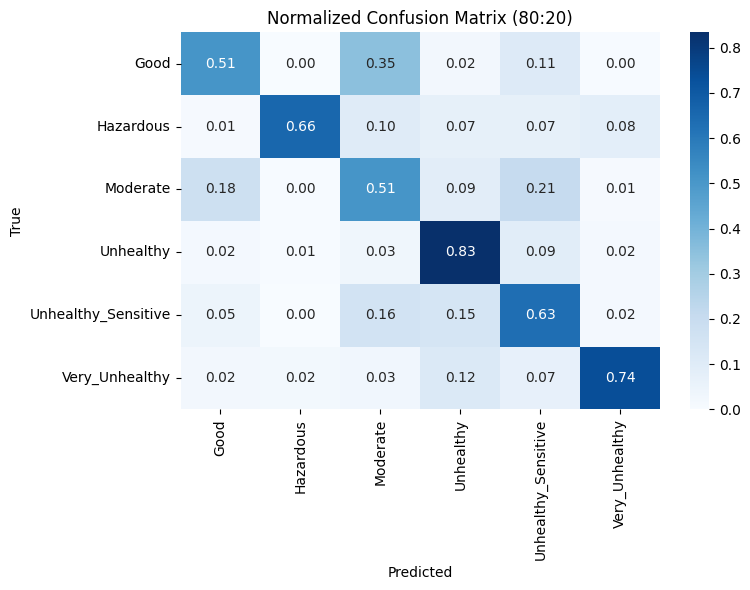

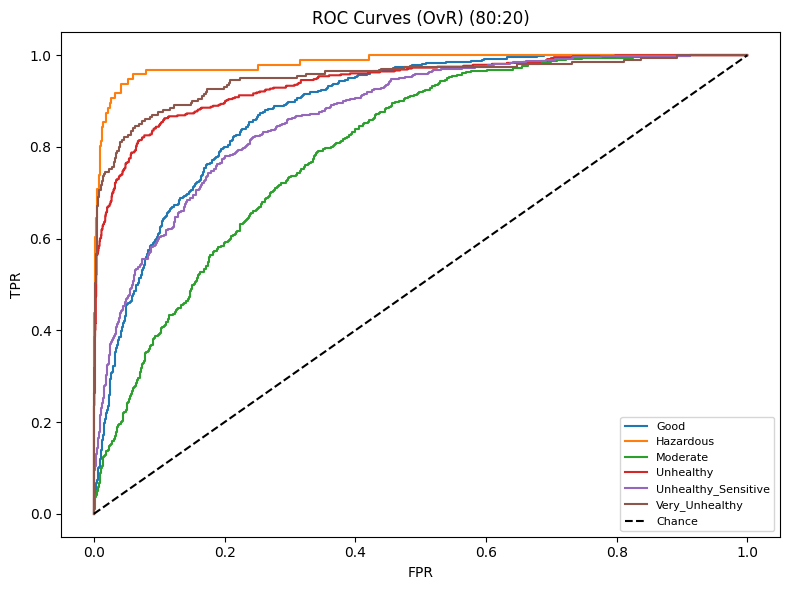


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.35
            Moderate → Unhealthy_Sensitive : 0.21
            Moderate → Good               : 0.18
  Unhealthy_Sensitive → Moderate           : 0.16
  Unhealthy_Sensitive → Unhealthy          : 0.15

[TEST] Ratio 70:30
Test Loss: 1.700, Test Accuracy: 0.613
Total Test Time: 27.82 seconds for 3331 images
Average Inference Time per Image: 0.008352 s (~8.35 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.645920
1            Hazardous  0.743056
2             Moderate  0.404432
3            Unhealthy  0.789474
4  Unhealthy_Sensitive  0.550139
5       Very_Unhealthy  0.698675

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5507    0.6459    0.5945       723
          Hazardous     0.7868    0.7431    0.7643       144
           Moderate     0.4665    0.4044    0.4332       722
          Unhealthy  

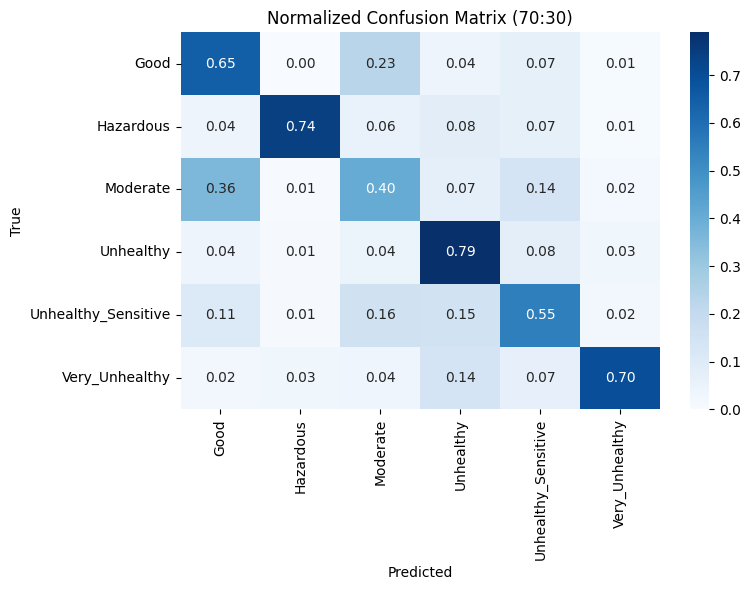

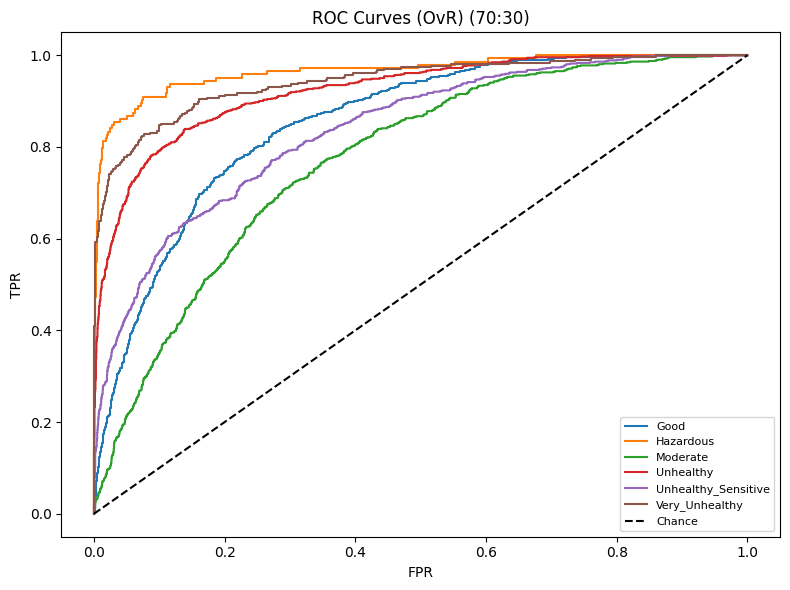


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.36
                Good → Moderate           : 0.23
  Unhealthy_Sensitive → Moderate           : 0.16
  Unhealthy_Sensitive → Unhealthy          : 0.15
            Moderate → Unhealthy_Sensitive : 0.14

[TEST] Ratio 60:40
Test Loss: 1.052, Test Accuracy: 0.597
Total Test Time: 36.41 seconds for 4442 images
Average Inference Time per Image: 0.008197 s (~8.20 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.553479
1            Hazardous  0.787565
2             Moderate  0.422638
3            Unhealthy  0.662513
4  Unhealthy_Sensitive  0.656217
5       Very_Unhealthy  0.729529

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5883    0.5535    0.5704       963
          Hazardous     0.5693    0.7876    0.6609       193
           Moderate     0.4487    0.4226    0.4353       963
          Unhealthy  

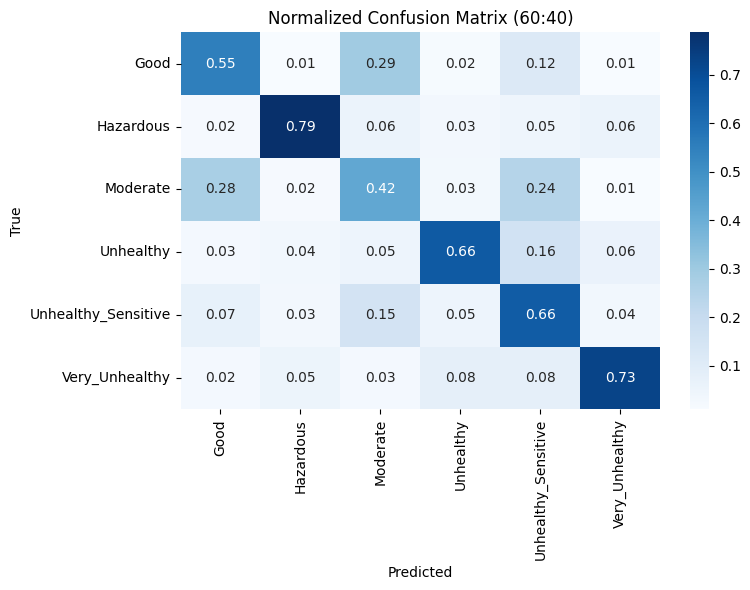

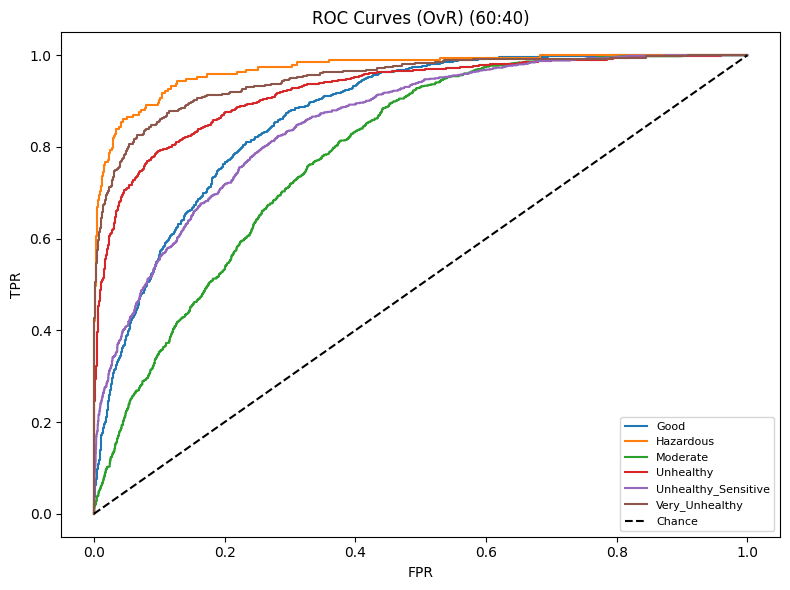


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.29
            Moderate → Good               : 0.28
            Moderate → Unhealthy_Sensitive : 0.24
           Unhealthy → Unhealthy_Sensitive : 0.16
  Unhealthy_Sensitive → Moderate           : 0.15

[TEST] Ratio 50:50
Test Loss: 1.828, Test Accuracy: 0.608
Total Test Time: 44.85 seconds for 5552 images
Average Inference Time per Image: 0.008077 s (~8.08 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.799834
1            Hazardous  0.737500
2             Moderate  0.241694
3            Unhealthy  0.727575
4  Unhealthy_Sensitive  0.569758
5       Very_Unhealthy  0.773360

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5045    0.7998    0.6187      1204
          Hazardous     0.7500    0.7375    0.7437       240
           Moderate     0.5553    0.2417    0.3368      1204
          Unhealthy  

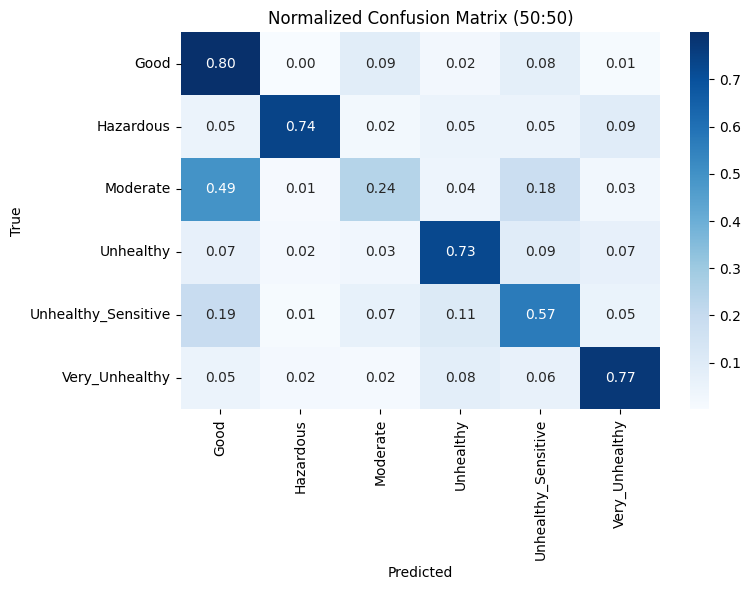

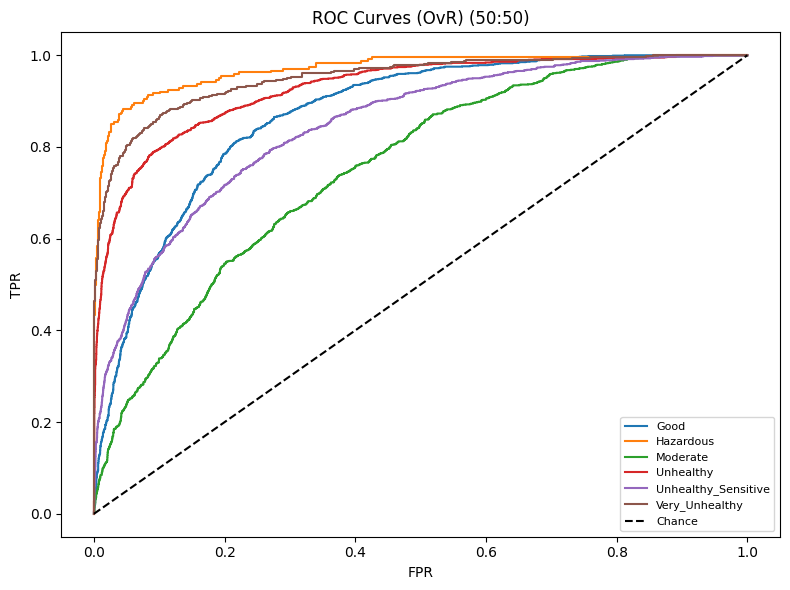


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.49
  Unhealthy_Sensitive → Good               : 0.19
            Moderate → Unhealthy_Sensitive : 0.18
  Unhealthy_Sensitive → Unhealthy          : 0.11
           Hazardous → Very_Unhealthy     : 0.09

[TEST] Ratio 40:60
Test Loss: 2.551, Test Accuracy: 0.516
Total Test Time: 53.60 seconds for 6662 images
Average Inference Time per Image: 0.008046 s (~8.05 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.464360
1            Hazardous  0.470588
2             Moderate  0.448061
3            Unhealthy  0.716759
4  Unhealthy_Sensitive  0.435237
5       Very_Unhealthy  0.533113

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5049    0.4644    0.4838      1445
          Hazardous     0.8344    0.4706    0.6018       289
           Moderate     0.3784    0.4481    0.4103      1444
          Unhealthy  

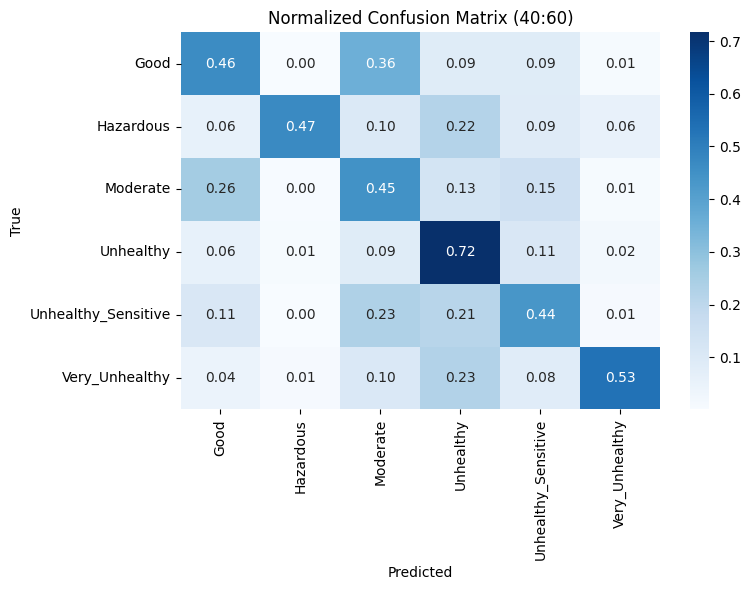

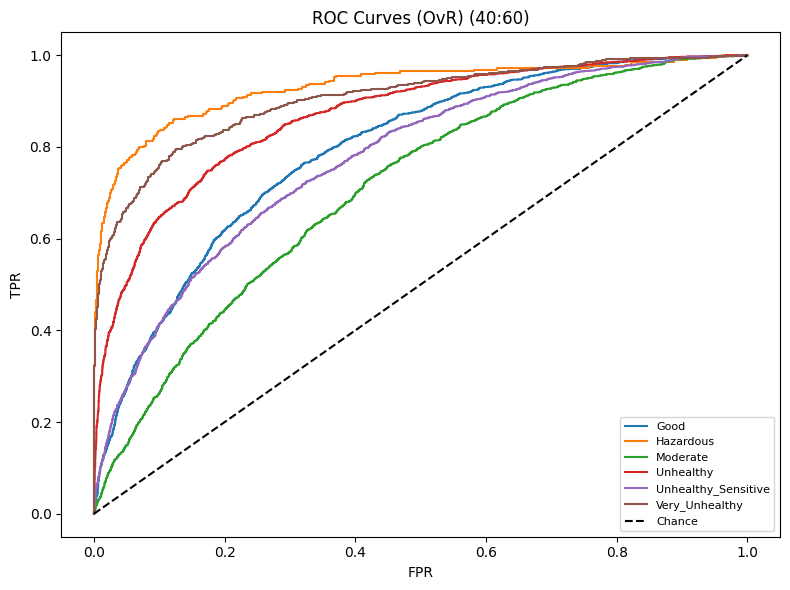


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.36
            Moderate → Good               : 0.26
  Unhealthy_Sensitive → Moderate           : 0.23
      Very_Unhealthy → Unhealthy          : 0.23
           Hazardous → Unhealthy          : 0.22

[TEST] Ratio 30:70
Test Loss: 2.378, Test Accuracy: 0.503
Total Test Time: 63.24 seconds for 7773 images
Average Inference Time per Image: 0.008136 s (~8.14 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.615065
1            Hazardous  0.563798
2             Moderate  0.249852
3            Unhealthy  0.621958
4  Unhealthy_Sensitive  0.450746
5       Very_Unhealthy  0.648227

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4790    0.6151    0.5386      1686
          Hazardous     0.5444    0.5638    0.5539       337
           Moderate     0.3862    0.2499    0.3034      1685
          Unhealthy    

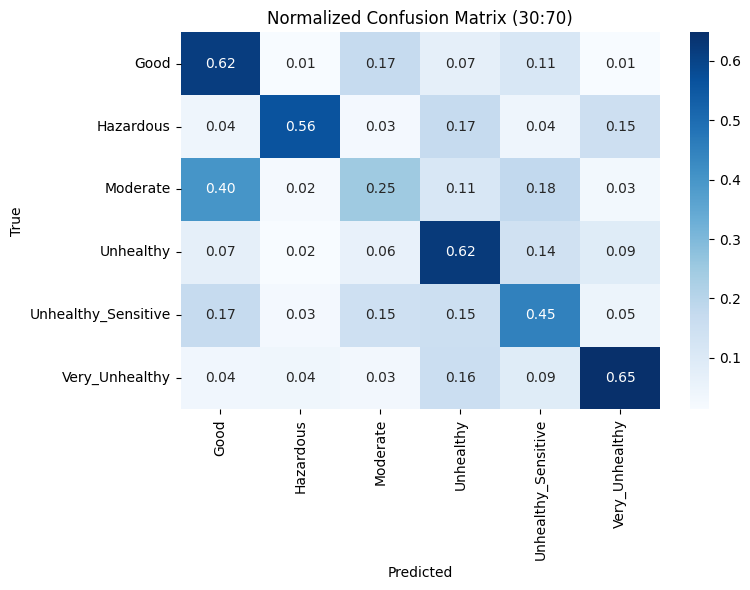

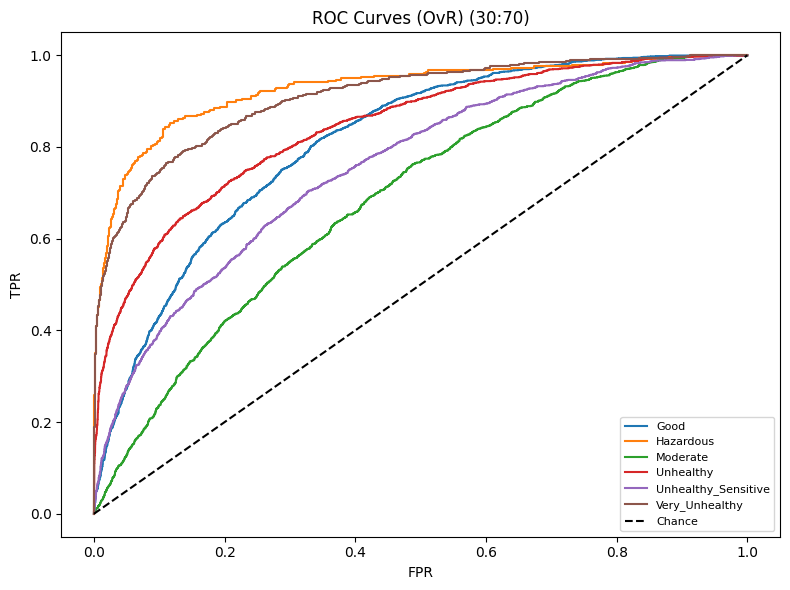


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.40
            Moderate → Unhealthy_Sensitive : 0.18
  Unhealthy_Sensitive → Good               : 0.17
           Hazardous → Unhealthy          : 0.17
                Good → Moderate           : 0.17

[TEST] Ratio 20:80
Test Loss: 2.431, Test Accuracy: 0.501
Total Test Time: 71.69 seconds for 8883 images
Average Inference Time per Image: 0.008070 s (~8.07 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.443406
1            Hazardous  0.485714
2             Moderate  0.357736
3            Unhealthy  0.642783
4  Unhealthy_Sensitive  0.492163
5       Very_Unhealthy  0.668734

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5439    0.4434    0.4886      1926
          Hazardous     0.7165    0.4857    0.5789       385
           Moderate     0.3734    0.3577    0.3654      1926
          Unhealthy   

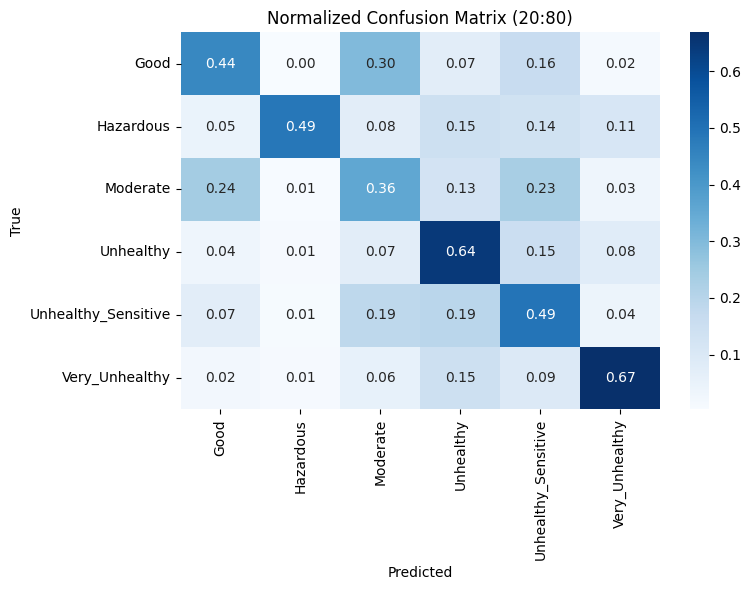

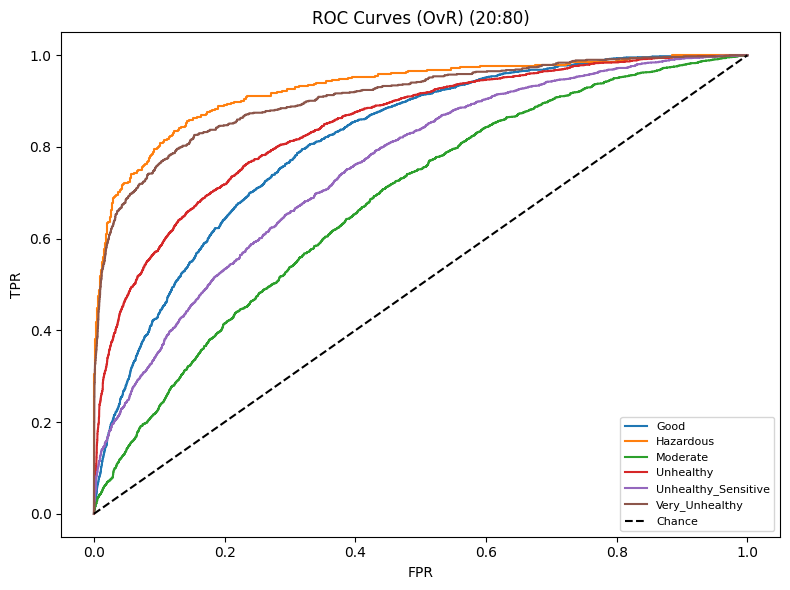


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.30
            Moderate → Good               : 0.24
            Moderate → Unhealthy_Sensitive : 0.23
  Unhealthy_Sensitive → Unhealthy          : 0.19
  Unhealthy_Sensitive → Moderate           : 0.19

[TEST] Ratio 10:90
Test Loss: 2.689, Test Accuracy: 0.394
Total Test Time: 80.65 seconds for 9993 images
Average Inference Time per Image: 0.008071 s (~8.07 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.322566
1            Hazardous  0.161663
2             Moderate  0.469312
3            Unhealthy  0.436750
4  Unhealthy_Sensitive  0.384401
5       Very_Unhealthy  0.421634

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4410    0.3226    0.3726      2167
          Hazardous     0.7000    0.1617    0.2627       433
           Moderate     0.3097    0.4693    0.3731      2167
          Unhealthy  

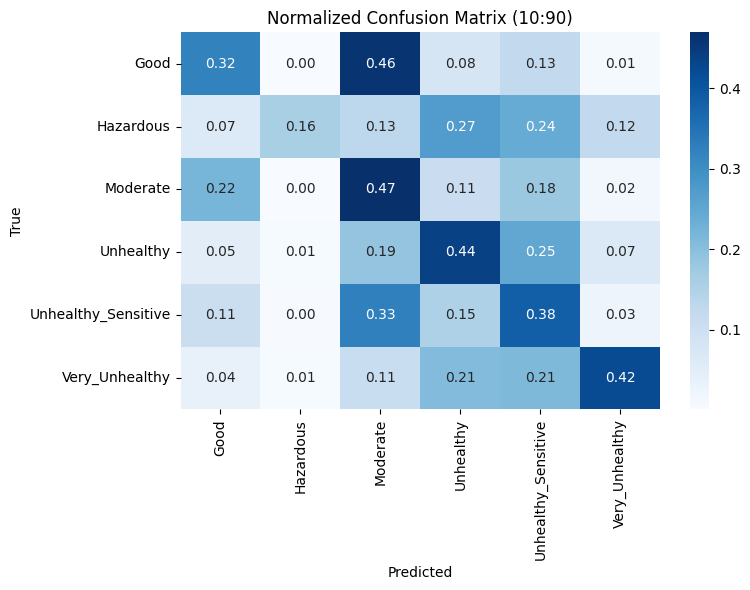

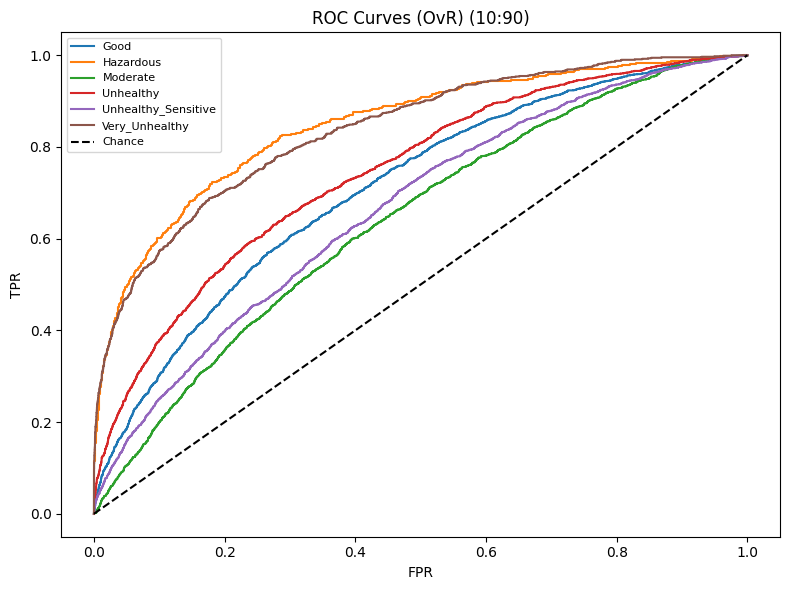


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.46
  Unhealthy_Sensitive → Moderate           : 0.33
           Hazardous → Unhealthy          : 0.27
           Unhealthy → Unhealthy_Sensitive : 0.25
           Hazardous → Unhealthy_Sensitive : 0.24


In [ ]:
import time
import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

CLASS_NAMES = sorted(df['label'].unique())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}

for (tr, te) in RATIOS:
    print(f"\n[TEST] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_vit_b16", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
    num_ftrs = model.heads.head.in_features
    model.heads.head = nn.Linear(num_ftrs, len(CLASS_NAMES))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_weight"])

    split = SPLITS[(tr, te)]
    _, _, dataloader_test_dataset = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    start_time = time.time()
    test_loss, test_accuracy, all_preds, all_labels, all_probs = evaluate_model(
        model, criterion, dataloader_test_dataset, return_preds=True
    )
    end_time = time.time()
    test_time = end_time - start_time

    n_test_images = len(split["test_df"])
    avg_inf_per_image_sec = test_time / n_test_images if n_test_images > 0 else float('nan')
    avg_inf_per_image_ms = avg_inf_per_image_sec * 1000.0

    print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_accuracy:.3f}")
    print(f"Total Test Time: {test_time:.2f} seconds for {n_test_images} images")
    print(f"Average Inference Time per Image: {avg_inf_per_image_sec:.6f} s (~{avg_inf_per_image_ms:.2f} ms/image)")

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_acc_df = pd.DataFrame({'Class': CLASS_NAMES, 'Accuracy': per_class_acc})
    print("\nPer-Class Accuracy:")
    print(per_class_acc_df)

    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
    print("\nClassification Report:\n")
    print(report)

    try:
        y_true_bin = label_binarize(all_labels, classes=np.arange(len(CLASS_NAMES)))
        macro_auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovr')
    except Exception:
        macro_auc = np.nan
    print(f"Macro ROC–AUC (OvR): {macro_auc if not np.isnan(macro_auc) else 'NA'}")

    plt.figure(figsize=(8, 6))
    import seaborn as sns
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')

    plt.title(f'Normalized Confusion Matrix ({tr}:{te})')
    cm_path = os.path.join(save_path_checkpoints, f'cm_norm_{tr}-{te}.png')
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()

    try:
        plt.figure(figsize=(8, 6))
        for i, cname in enumerate(CLASS_NAMES):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
            plt.plot(fpr, tpr, label=cname)
        plt.plot([0, 1], [0, 1], 'k--', label='Chance')
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.title(f'ROC Curves (OvR) ({tr}:{te})')
        plt.legend(fontsize=8)
        roc_path = os.path.join(save_path_checkpoints, f'roc_{tr}-{te}.png')
        plt.tight_layout()
        plt.savefig(roc_path)
        plt.show()
    except Exception:
        pass

    cm_norm_off = cm_norm.copy()
    np.fill_diagonal(cm_norm_off, 0.0)

    confused = []
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            if i == j:
                continue
            confused.append((CLASS_NAMES[i], CLASS_NAMES[j], cm_norm_off[i, j]))
    confused.sort(key=lambda x: x[2], reverse=True)
    top_k = [c for c in confused if np.isfinite(c[2]) and c[2] > 0][:5]
    if top_k:
        print("\nTop Confused Pairs (True → Pred, rate):")
        for (t, p, r) in top_k:
            print(f"  {t:>18s} → {p:<18s} : {r:.2f}")
    else:
        print("\nNo significant confused pairs detected.")
